# Neural Network - 1D-CNN excecution

This notebook trains neural network models based on the paper [incluir citas].

The model implemented is `1dcnn` → Conv1D block + 4 Dense layers + Batch Normalization + Dropout.

This program:
1. 
2. 
3. 
4. 
5. 

This notebook expects the files generated by the preprocessing notebook:

- `Dataset/train/preprocessed_train.csv`
- `Dataset/test/preprocessed_test.csv`


## Imports

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import json

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger, ReduceLROnPlateau


## 1. Load preprocessed datasets

In [128]:
train_df = pd.read_csv("../../Dataset/train/preprocessed_train.csv")
test_df = pd.read_csv("../../Dataset/test/preprocessed_test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (3918, 12)
Test shape: (980, 12)


,alcohol,density,residual sugar,total sulfur dioxide,free sulfur dioxide,chlorides,citric acid,fixed acidity,pH,sulphates,volatile acidity,quality
0,0.811436,-1.015152,-0.396463,0.273654,0.090254,-0.876675,-0.777631,-1.476971,0.727373,-1.572934,-0.676949,7
1,1.954627,-1.633570,-0.945154,-0.762947,0.265528,-0.502390,-0.199185,-0.773832,0.465637,-0.870325,0.225769,7
2,-0.903350,0.248282,-0.376867,0.839073,1.492444,9.088661,-0.116550,-0.539453,-0.450439,-0.079891,-0.075137,5
3,0.893092,-1.477303,-1.023539,-0.998539,-0.201869,-0.455604,0.048721,-0.656643,-0.843043,2.203587,-0.576647,6
4,1.056405,-1.181394,-0.435656,-0.904302,0.090254,-0.783104,-1.438712,-1.828540,0.727373,-1.133804,0.225769,8


## 2. Separate attributes and labels

In [129]:
X_train = train_df.drop("quality", axis=1).astype("float32")
y_train = train_df["quality"].astype("int32")

X_test = test_df.drop("quality", axis=1).astype("float32")
y_test = test_df["quality"].astype("int32")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTest class distribution:")
print(y_test.value_counts().sort_index())


X_train: (3918, 11)
y_train: (3918,)
X_test: (980, 11)
y_test: (980,)

Training class distribution:
quality
3      16
4     130
5    1166
6    1758
7     704
8     140
9       4
Name: count, dtype: int64

Test class distribution:
quality
3      4
4     33
5    291
6    440
7    176
8     35
9      1
Name: count, dtype: int64


## 3. Encode labels

Wine quality labels are not always `0, 1, 2, ...`.

For neural networks, we encode them before training.

Example:

`3 → 0`, `4 → 1`, `5 → 2`, etc.


In [130]:
encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train).astype("int32")
y_test_encoded = encoder.transform(y_test).astype("int32")

num_classes = len(encoder.classes_)
num_attributes = X_train.shape[1]

# print("Classes on dataset:", encoder.classes_)
# print("Number of classes:", num_classes)
# print("Number of attributes:", num_attributes)

print("Encoder classes:")
print(encoder.classes_)

Encoder classes:
[3 4 5 6 7 8 9]


## 4. Import model

In [913]:
sys.path.append(os.path.abspath("../../"))

from models.oneD_CNN_model import create_model 

model = create_model(num_classes=num_classes, num_attributes=num_attributes)

model.summary()

Model: "wine_quality_1d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_block (Conv1D)           │ (None, 11, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 352)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        45,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_128                  │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_128 (Activation)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_128 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_64                   │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_64 (Activation)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_32                   │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_32 (Activation)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ quality_output (Dense)          │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,191 (223.40 KB)

 Trainable params: 56,743 (221.65 KB)

 Non-trainable params: 448 (1.75 KB)

## 5. Compile model

In [914]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 6. Train model & callbacks

In [990]:
best_model_checkpoint = ModelCheckpoint(
    filepath="../../models/1D_CNN_checkpoints/best_1D_CNN_model.keras",
    monitor="val_loss",
    mode="max",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# save model certain N epochs
class SaveModelEveryNEpochs(tf.keras.callbacks.Callback):
    def __init__(self, save_dir, every=10, prefix="1D_CNN"):
        super().__init__()
        self.save_dir = Path(save_dir)
        self.every = every
        self.prefix = prefix
        self.save_dir.mkdir(parents=True, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        current_epoch = epoch + 1

        if current_epoch % self.every == 0:
            logs = logs or {}
            val_loss = logs.get("val_loss")

            if val_loss is not None:
                filename = f"{self.prefix}_epoch_{current_epoch}_val_loss_{val_loss:.4f}.keras"

            model_path = self.save_dir / filename
            self.model.save(model_path)

periodic_checkpoint = SaveModelEveryNEpochs(
    save_dir="../../models/1D_CNN_periodic_checkpoints",
    every=10
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    mode="max",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

csv_logger = CSVLogger(
    filename="../../models/1D_CNN_periodic_checkpoints/1D_CNN_training_log.csv",
    append=False
)

callbacks = [
    best_model_checkpoint,
    periodic_checkpoint,
    early_stopping,
    csv_logger
]

history = model.fit(
    X_train,
    y_train_encoded,
    epochs=100,
    batch_size=64,
    validation_split=.2,
    callbacks=callbacks
)


Epoch 1/100
46/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8257 - loss: 0.4422
Epoch 1: val_loss improved from None to 1.32205, saving model to ../../models/1D_CNN_checkpoints/best_1D_CNN_model.keras

Epoch 1: finished saving model to ../../models/1D_CNN_checkpoints/best_1D_CNN_model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8322 - loss: 0.4404 - val_accuracy: 0.6352 - val_loss: 1.3220
Epoch 2/100
40/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8482 - loss: 0.3851
Epoch 2: val_loss did not improve from 1.32205
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8430 - loss: 0.3984 - val_accuracy: 0.6378 - val_loss: 1.3113
Epoch 3/100
41/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8310 - loss: 0.4260
Epoch 3: val_loss did not improve from 1.32205
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8232 - loss: 0.4443 - val_accuracy: 0.6327 - val_loss: 1.3125
Epoch 4/100
40/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8233 - loss: 0.4443
Epoch 4: 

## 7. Training behavior plots

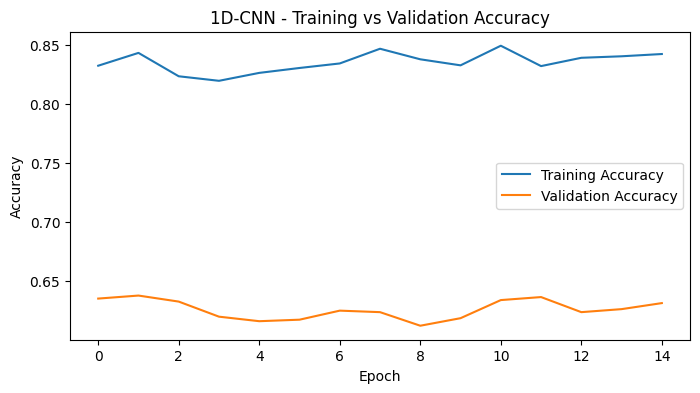

In [991]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("1D-CNN - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


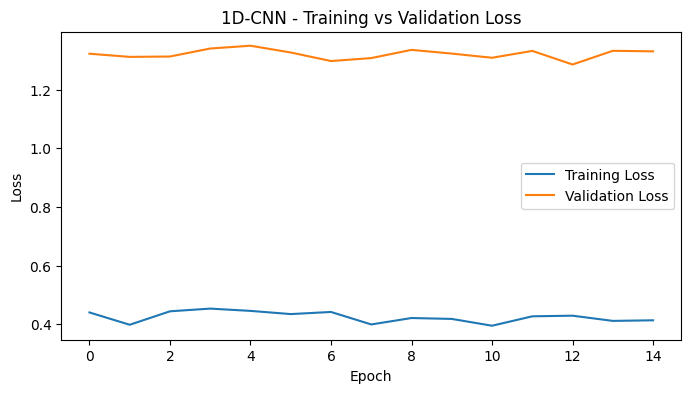

In [992]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("1D-CNN - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


## 8. Predictions

In [993]:
y_train_pred_probs = model.predict(X_train)
y_test_pred_probs = model.predict(X_test)

print(y_test_pred_probs[:5])

y_train_pred = np.argmax(y_train_pred_probs, axis=1)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[2.52863856e-06 2.64530377e-06 8.34323525e-01 1.65631995e-01
  3.93022565e-05 1.92075902e-08 5.38173542e-12]
 [1.97599022e-07 5.40825840e-06 6.91587292e-03 7.80691862e-01
  2.12043390e-01 3.43185937e-04 1.26600952e-07]
 [2.38961235e-04 1.34018986e-02 1.44738212e-01 8.15005958e-01
  2.28911731e-02 3.71209602e-03 1.16816973e-05]
 [1.39766025e-05 4.44323802e-03 2.45041586e-03 5.15762031e-01
  9.74290445e-02 3.79163891e-01 7.37459981e-04]
 [1.27397087e-07 7.14887574e-05 4.41481534e-04 7.79951692e-01
  2.17752412e-01 1.78134639e-03 1.44441947e-06]]


## 9. Metrics

In [994]:
def evaluate_model(y_true, y_pred, dataset_name):
    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"{dataset_name} Results")
    print("---------------------")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    return {
        "dataset": dataset_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }


In [995]:
train_metrics = evaluate_model(y_train_encoded, y_train_pred, "Training")
print()
test_metrics = evaluate_model(y_test_encoded, y_test_pred, "Test")

Training Results
---------------------
Accuracy : 0.8897
Precision: 0.8890
Recall   : 0.8897
F1 Score : 0.8888

Test Results
---------------------
Accuracy : 0.6316
Precision: 0.6251
Recall   : 0.6316
F1 Score : 0.6260


## 10. Classification report

In [996]:
print(
    classification_report(
        y_test_encoded,
        y_test_pred,
        target_names=[str(label) for label in encoder.classes_],
        zero_division=0
    )
)


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.43      0.18      0.26        33
           5       0.65      0.63      0.64       291
           6       0.65      0.70      0.67       440
           7       0.61      0.59      0.60       176
           8       0.50      0.49      0.49        35
           9       0.00      0.00      0.00         1

    accuracy                           0.63       980
   macro avg       0.41      0.37      0.38       980
weighted avg       0.63      0.63      0.63       980



## 11. Confusion matrix

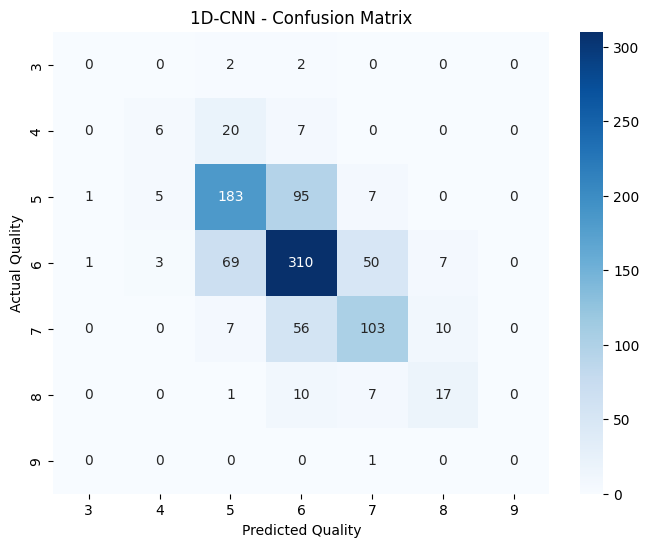

In [997]:
cm = confusion_matrix(
    y_test_encoded,
    y_test_pred
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("1D-CNN - Confusion Matrix")
plt.xlabel("Predicted Quality")
plt.ylabel("Actual Quality")
plt.show()
